# Example-12: SKIF FOFB

In [1]:
# Import

import re
import numpy
import pandas
import torch
import yaml

import sys
sys.path.append('..')

from harmonica.util import mod
from harmonica.statistics import mean, variance
from harmonica.statistics import weighted_mean, weighted_variance
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter
from harmonica.decomposition import Decomposition
from harmonica.model import Model
from harmonica.table import Table

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())

True


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

In [3]:
# In this example orbit responce is computed for SKIF fast correctors
# Errors are added to standalone quadrupoles

True


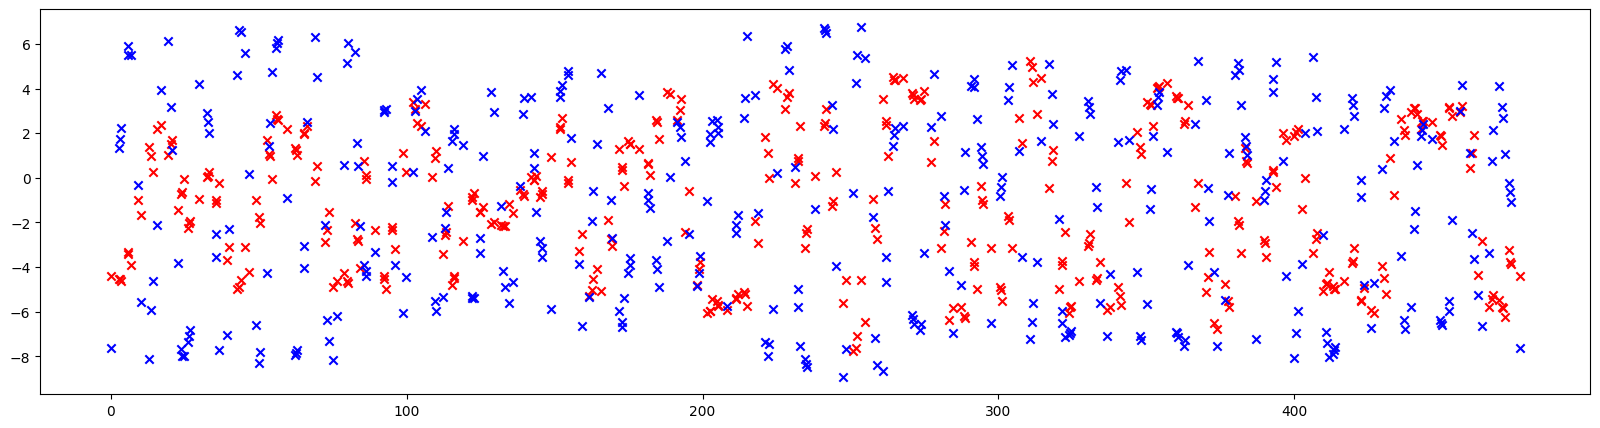

In [4]:
# Set model

model = Model(path='../fast.yaml', model='uncoupled', dtype=dtype, device=device)

# Set monitor locations (ID monitors)

lm = [model.name.index(name) for name in model.name if re.match(r'^(MA).*\.PKA[1, 2]', name)]

# Set fast corrector locations

lc = [model.name.index(name) for name in model.name if re.match(r'^(MA).*\.CB.*\.CX', name)]

# Set standalone quadrupole locations

lq = [model.name.index(name) for name in model.name if re.match(r'^(MA).*\.Q[F, D]', name)]

# Set quadrupole errors

kn = torch.zeros(model.size, dtype=dtype, device=device)
ks = torch.zeros(model.size, dtype=dtype, device=device)
kl = 0.0

kn[lq] += 1.0E-3*torch.randn(len(lq), dtype=dtype, device=device)
ks[lq] += 1.0E-3*torch.randn(len(lq), dtype=dtype, device=device)

# Set corrector errors

cx = torch.zeros(model.size, dtype=dtype, device=device)
cy = torch.zeros(model.size, dtype=dtype, device=device)

cx[lq] += 10.0E-6*torch.randn(len(lq), dtype=dtype, device=device)
cy[lq] += 10.0E-6*torch.randn(len(lq), dtype=dtype, device=device)

# Make errors

model.make_error(kn, ks, length=kl, angle_x=cx, angle_y=cy)

# Make transport

model.make_transport(error=True, exact=False, method='BFGS', tol=1.0E-12)

# Make twiss

model.make_twiss()
print(model.is_stable)

# Compare twiss

AX, BX, AY, BY = model.out_cs.T

plt.figure(figsize=(20, 5))
plt.scatter(model.time.cpu().numpy(), 100*(BX - model.bx)/model.bx, color='red', marker='x')
plt.scatter(model.time.cpu().numpy(), 100*(BY - model.by)/model.by, color='blue', marker='x')
plt.show()

In [5]:
# Compute responce matrix using model transport and transport with errors

responce_model = model.make_responce(lc, lm, model.matrix)
responce_error = model.make_responce(lc, lm, model.matrix_transport)

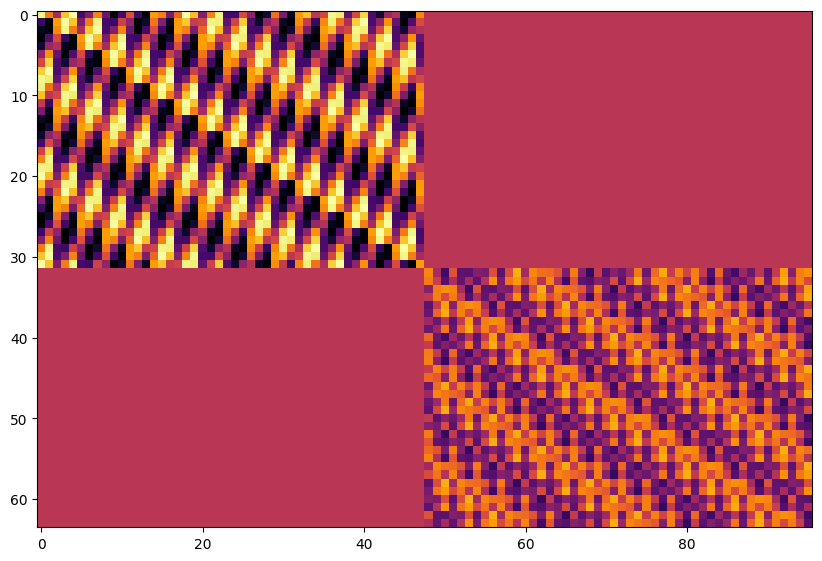

In [6]:
# Plot responce matrix (model)

plt.figure(figsize=(10, 10))
plt.imshow(responce_model.cpu().numpy(), cmap='inferno')
plt.show()

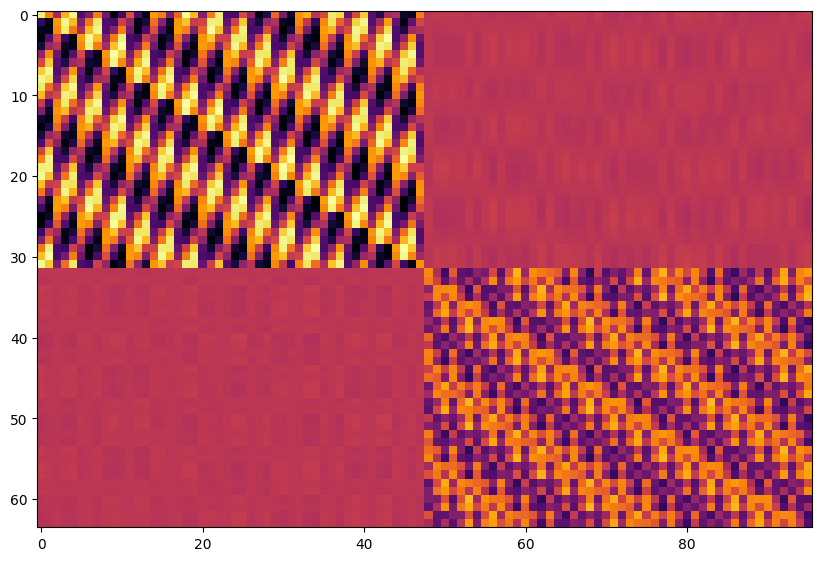

In [7]:
# Plot responce matrix (error)

plt.figure(figsize=(10, 10))
plt.imshow(responce_error.cpu().numpy(), cmap='inferno')
plt.show()

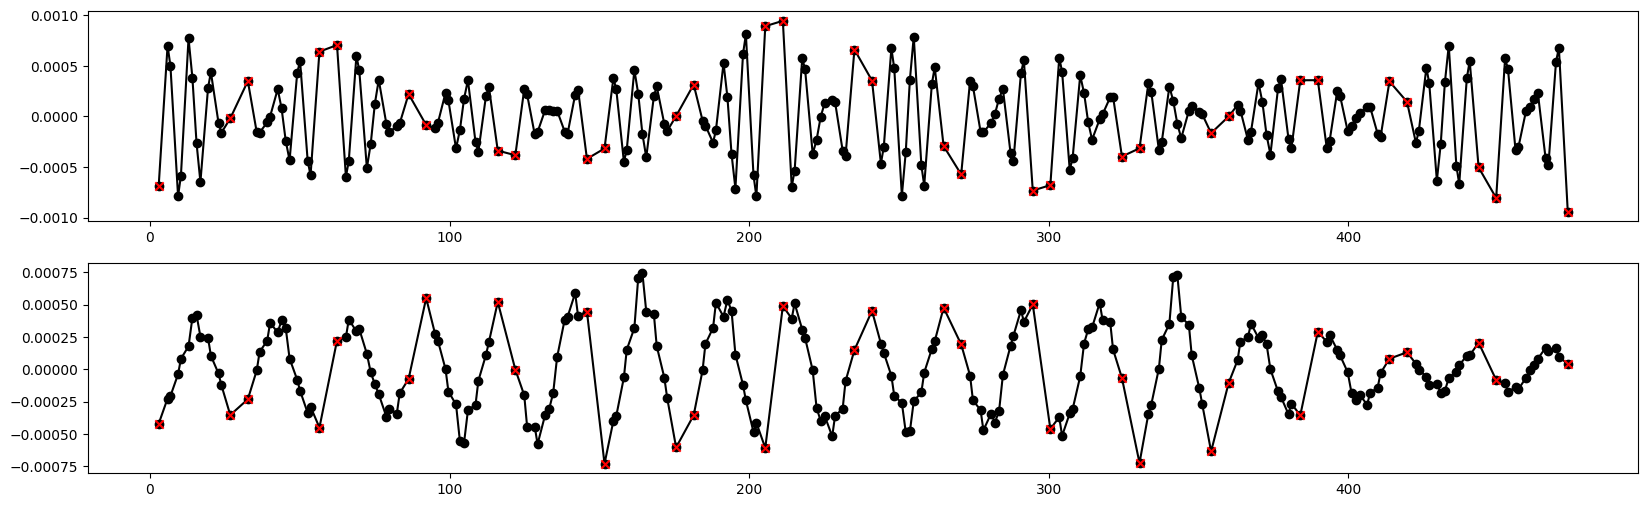

In [8]:
# Plot orbit at monitors with errors

# black -- orbit at all monitors
# red   -- orbit at ID monitors

x, _, y, _ = torch.clone(model.orbit.T)

plt.figure(figsize=(20, 2*3))

ax = plt.subplot(211)
ax.plot(model.time[model.monitor_index].cpu().numpy(), x[model.monitor_index].cpu().numpy(), color='black', marker='o', zorder=0)
ax.scatter(model.time[lm].cpu().numpy(), x[lm].cpu().numpy(), color='red', marker='x', zorder=1)

ax = plt.subplot(212)
ax.plot(model.time[model.monitor_index].cpu().numpy(), y[model.monitor_index].cpu().numpy(), color='black', marker='o', zorder=0)
ax.scatter(model.time[lm].cpu().numpy(), y[lm].cpu().numpy(), color='red', marker='x', zorder=1)

plt.show()

In [9]:
# Set fast correctors using model responce matrix

ax, ay = (torch.linalg.pinv(responce_model) @ torch.cat([x[lm], y[lm]])).reshape(-1, len(lc))
cx[lc] = -ax
cy[lc] = -ay

model.make_error(kn, ks, length=kl, angle_x=cx, angle_y=cy)
model.make_transport(error=True, exact=False, method='BFGS', tol=1.0E-12)

x_model, _, y_model, _ = torch.clone(model.orbit.T)

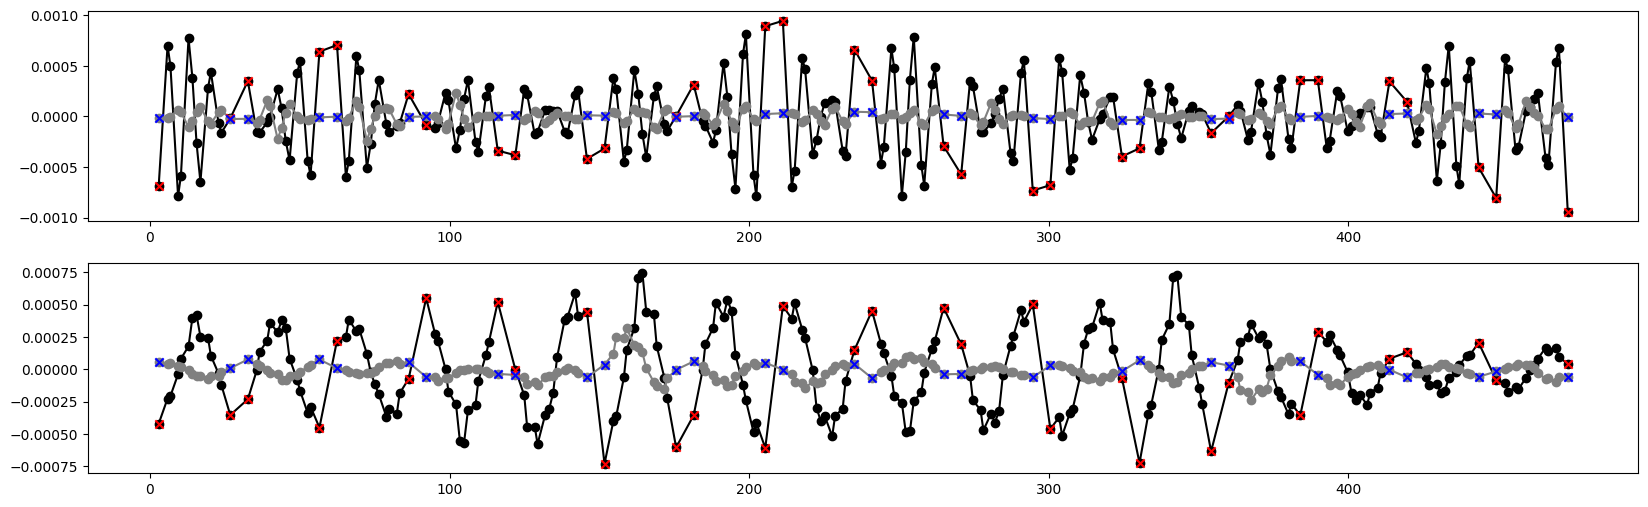

In [10]:
# Compare orbits

plt.figure(figsize=(20, 2*3))

ax = plt.subplot(211)
ax.plot(model.time[model.monitor_index].cpu().numpy(), x[model.monitor_index].cpu().numpy(), color='black', marker='o', zorder=0)
ax.scatter(model.time[lm].cpu().numpy(), x[lm].cpu().numpy(), color='red', marker='x', zorder=1)
ax.plot(model.time[model.monitor_index].cpu().numpy(), x_model[model.monitor_index].cpu().numpy(), color='gray', marker='o', zorder=0)
ax.scatter(model.time[lm].cpu().numpy(), x_model[lm].cpu().numpy(), color='blue', marker='x', zorder=1)

ax = plt.subplot(212)
ax.plot(model.time[model.monitor_index].cpu().numpy(), y[model.monitor_index].cpu().numpy(), color='black', marker='o', zorder=0)
ax.scatter(model.time[lm].cpu().numpy(), y[lm].cpu().numpy(), color='red', marker='x', zorder=1)
ax.plot(model.time[model.monitor_index].cpu().numpy(), y_model[model.monitor_index].cpu().numpy(), color='gray', marker='o', zorder=0)
ax.scatter(model.time[lm].cpu().numpy(), y_model[lm].cpu().numpy(), color='blue', marker='x', zorder=1)

plt.show()

In [11]:
# Set fast correctors using error responce matrix

ax, ay = (torch.linalg.pinv(responce_error) @ torch.cat([x[lm], y[lm]])).reshape(-1, len(lc))
cx[lc] = -ax
cy[lc] = -ay

model.make_error(kn, ks, length=kl, angle_x=cx, angle_y=cy)
model.make_transport(error=True, exact=False, method='BFGS', tol=1.0E-12)

x_error, _, y_error, _ = torch.clone(model.orbit.T)

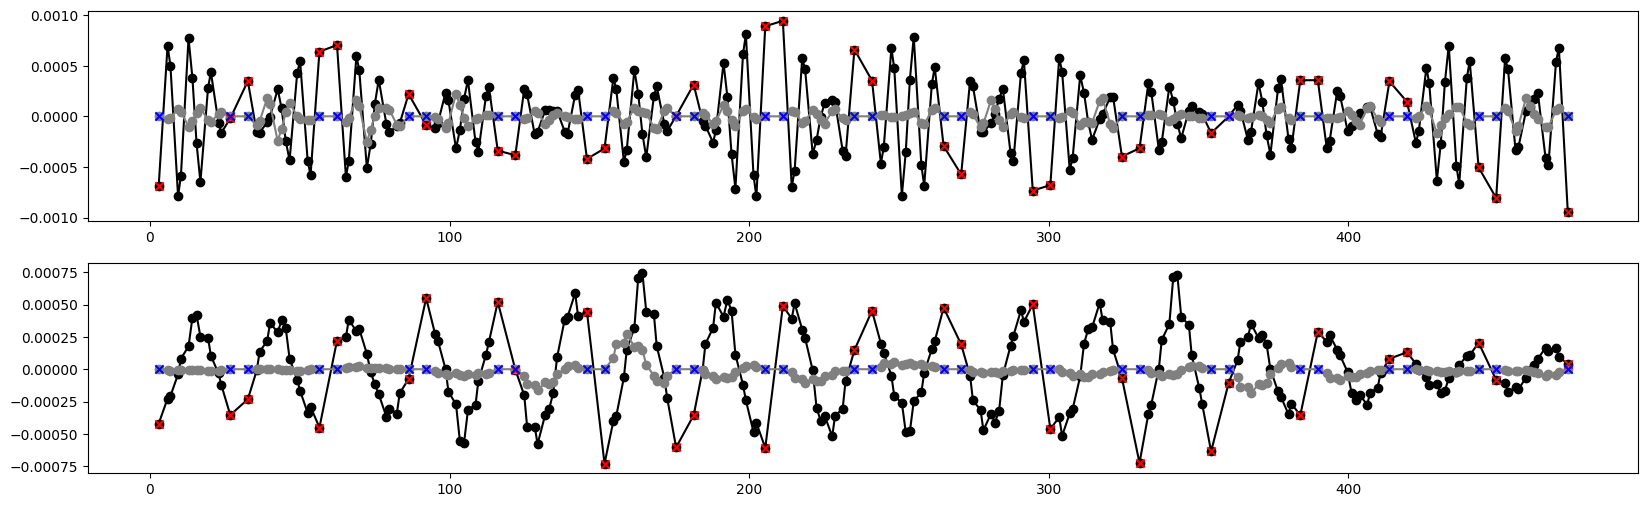

In [12]:
# Compare orbits

plt.figure(figsize=(20, 2*3))

ax = plt.subplot(211)
ax.plot(model.time[model.monitor_index].cpu().numpy(), x[model.monitor_index].cpu().numpy(), color='black', marker='o', zorder=0)
ax.scatter(model.time[lm].cpu().numpy(), x[lm].cpu().numpy(), color='red', marker='x', zorder=1)
ax.plot(model.time[model.monitor_index].cpu().numpy(), x_error[model.monitor_index].cpu().numpy(), color='gray', marker='o', zorder=0)
ax.scatter(model.time[lm].cpu().numpy(), x_error[lm].cpu().numpy(), color='blue', marker='x', zorder=1)

ax = plt.subplot(212)
ax.plot(model.time[model.monitor_index].cpu().numpy(), y[model.monitor_index].cpu().numpy(), color='black', marker='o', zorder=0)
ax.scatter(model.time[lm].cpu().numpy(), y[lm].cpu().numpy(), color='red', marker='x', zorder=1)
ax.plot(model.time[model.monitor_index].cpu().numpy(), y_error[model.monitor_index].cpu().numpy(), color='gray', marker='o', zorder=0)
ax.scatter(model.time[lm].cpu().numpy(), y_error[lm].cpu().numpy(), color='blue', marker='x', zorder=1)

plt.show()

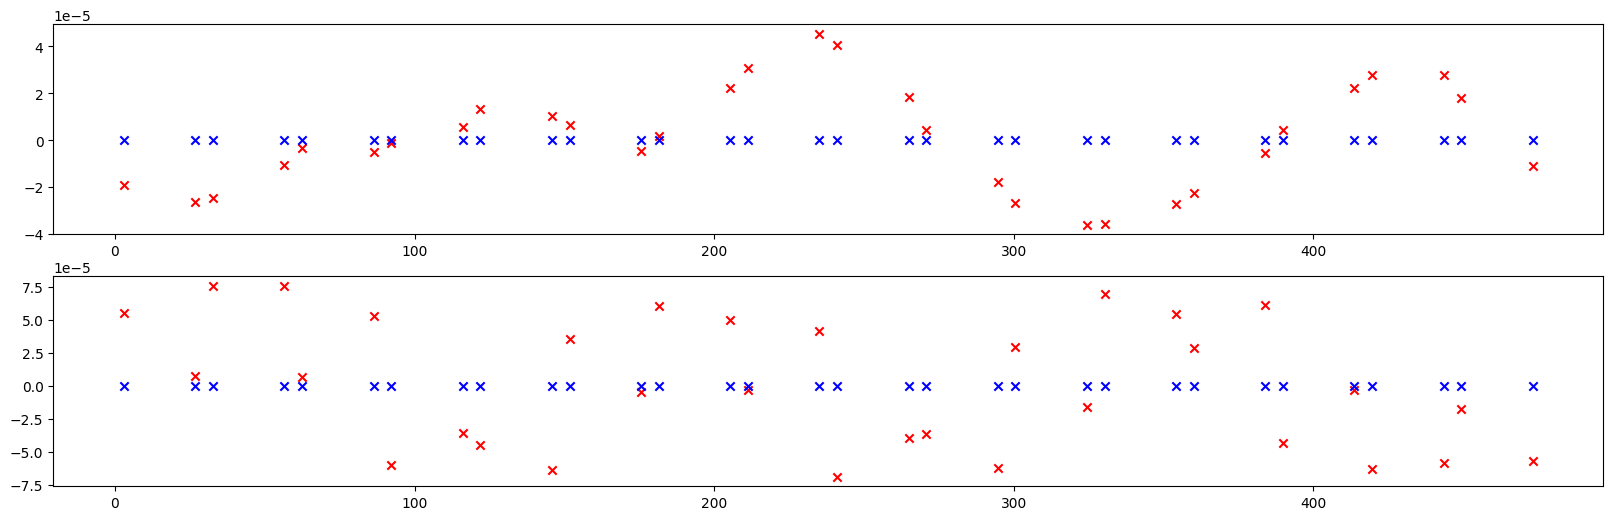

tensor(1.394724603463e-02, dtype=torch.float64)
tensor(5.778532345584e-04, dtype=torch.float64)
tensor(2.572538742137e-15, dtype=torch.float64)

tensor(1.101390556422e-02, dtype=torch.float64)
tensor(1.381319191528e-03, dtype=torch.float64)
tensor(2.401464573960e-16, dtype=torch.float64)



In [13]:
# Compare corrected orbits at ID monitors

plt.figure(figsize=(20, 2*3))

ax = plt.subplot(211)
ax.scatter(model.time[lm].cpu().numpy(), x_model[lm].cpu().numpy(), color='red', marker='x', zorder=0)
ax.scatter(model.time[lm].cpu().numpy(), x_error[lm].cpu().numpy(), color='blue', marker='x', zorder=1)

ax = plt.subplot(212)
ax.scatter(model.time[lm].cpu().numpy(), y_model[lm].cpu().numpy(), color='red', marker='x', zorder=0)
ax.scatter(model.time[lm].cpu().numpy(), y_error[lm].cpu().numpy(), color='blue', marker='x', zorder=1)

plt.show()

print(x[lm].abs().sum())
print(x_model[lm].abs().sum())
print(x_error[lm].abs().sum())
print()

print(y[lm].abs().sum())
print(y_model[lm].abs().sum())
print(y_error[lm].abs().sum())
print()